In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

data_dir = '/kaggle/input/sign-language-digits-dataset'
X = np.load(f'{data_dir}/X.npy').astype('float32') / 255.0
Y = np.load(f'{data_dir}/Y.npy')


if X.ndim == 3:  # grayscale images without channel
    X = np.expand_dims(X, axis=-1)


In [2]:

# Y is one-hot encoded: shape (num_samples, 10)
Y_int = np.argmax(Y, axis=1)  # now shape (num_samples,), values 0-9



In [3]:
label_map = {0:"Zero",1:"One",2:"Two",3:"Three",4:"Four",
             5:"Five",6:"Six",7:"Seven",8:"Eight",9:"Nine"}

Y_decoded = np.array([label_map[i] for i in Y_int])
print(Y_decoded[:10])


['Zero' 'Zero' 'Zero' 'Zero' 'Zero' 'Zero' 'Zero' 'Zero' 'Zero' 'Zero']


In [4]:
df = pd.DataFrame({
    'label': Y_decoded,
    'height': [img.shape[0] for img in X],
    'width': [img.shape[1] for img in X],
    'channels': [img.shape[2] for img in X],
    'mean_pixel': [img.mean() for img in X],
    'std_pixel': [img.std() for img in X],
    'min_pixel': [img.min() for img in X],
    'max_pixel': [img.max() for img in X]
})


In [5]:
df

,label,height,width,channels,mean_pixel,std_pixel,min_pixel,max_pixel
0,Zero,64,64,1,0.002634,0.000559,0.000754,0.003799
1,Zero,64,64,1,0.002657,0.000636,0.000677,0.003799
2,Zero,64,64,1,0.002698,0.000577,0.000677,0.003768
3,Zero,64,64,1,0.002617,0.000603,0.000769,0.003737
4,Zero,64,64,1,0.002761,0.000578,0.000569,0.003799
...,...,...,...,...,...,...,...,...
2057,Nine,64,64,1,0.002456,0.000623,0.000446,0.003752
2058,Nine,64,64,1,0.002639,0.000593,0.000338,0.003814
2059,Nine,64,64,1,0.002525,0.000573,0.000815,0.003722
2060,Nine,64,64,1,0.002655,0.000601,0.000661,0.003768


In [6]:
df.head()

,label,height,width,channels,mean_pixel,std_pixel,min_pixel,max_pixel
0,Zero,64,64,1,0.002634,0.000559,0.000754,0.003799
1,Zero,64,64,1,0.002657,0.000636,0.000677,0.003799
2,Zero,64,64,1,0.002698,0.000577,0.000677,0.003768
3,Zero,64,64,1,0.002617,0.000603,0.000769,0.003737
4,Zero,64,64,1,0.002761,0.000578,0.000569,0.003799


In [7]:
df.describe()

,height,width,channels,mean_pixel,std_pixel,min_pixel,max_pixel
count,2062.0,2062.0,2062.0,2062.000000,2062.000000,2062.000000,2062.000000
mean,64.0,64.0,1.0,0.002670,0.000616,0.000599,0.003777
std,0.0,0.0,0.0,0.000150,0.000050,0.000209,0.000060
min,64.0,64.0,1.0,0.002153,0.000488,0.000015,0.003137
25%,64.0,64.0,1.0,0.002593,0.000582,0.000461,0.003752
50%,64.0,64.0,1.0,0.002656,0.000608,0.000631,0.003783
75%,64.0,64.0,1.0,0.002712,0.000639,0.000754,0.003814
max,64.0,64.0,1.0,0.003287,0.000856,0.001153,0.003922


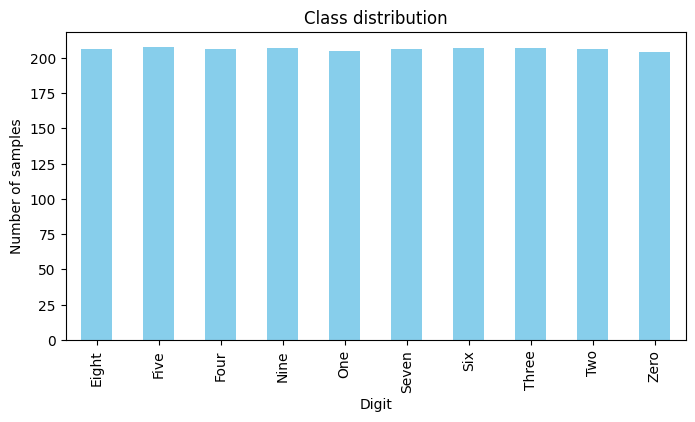

In [8]:
import matplotlib.pyplot as plt

# If you want integer labels
df['label'].value_counts().sort_index().plot(
    kind='bar', figsize=(8,4), color='skyblue', title='Class distribution'
)
plt.xlabel('Digit')
plt.ylabel('Number of samples')
plt.show()


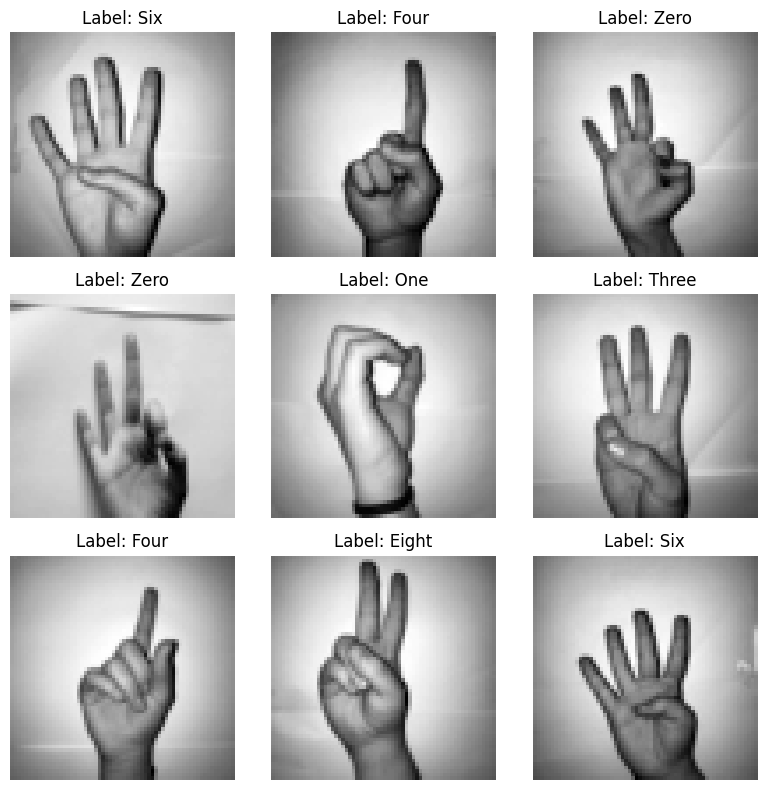

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Suppose X has shape (num_samples, H, W, C)
# Y_decoded is an array of decoded labels (strings)

num_samples = X.shape[0]

# Pick 9 random indices
random_indices = np.random.choice(num_samples, size=9, replace=False)

plt.figure(figsize=(8,8))
for i, idx in enumerate(random_indices):
    plt.subplot(3,3,i+1)
    img = X[idx]
    # If grayscale, remove the channel dimension
    if img.shape[2] == 1:
        img = img.squeeze()
    plt.imshow(img, cmap='gray')
    plt.title(f'Label: {Y_decoded[idx]}')
    plt.axis('off')

plt.tight_layout()
plt.show()


In [10]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# ------------------------
# Data prep
# ------------------------
X_train, X_val, Y_train_int, Y_val_int = train_test_split(X, Y_int, test_size=0.2, random_state=42)
Y_train = to_categorical(Y_train_int, num_classes=10)
Y_val   = to_categorical(Y_val_int, num_classes=10)

2025-11-21 06:33:39.725693: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763706820.067274      39 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763706820.169031      39 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [11]:
print("Train class distribution:", np.bincount(Y_train_int))
print("Val class distribution:", np.bincount(Y_val_int))


Train class distribution: [164 157 156 172 174 170 166 168 161 161]
Val class distribution: [40 48 50 35 32 38 41 38 45 46]


In [12]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

from sklearn.metrics import classification_report



# ------------------------
# Simpler CNN model
# ------------------------
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

from tensorflow.keras.callbacks import Callback

class StopOnValAccuracy(Callback):
    def __init__(self, threshold=0.95):
        super().__init__()
        self.threshold = threshold

    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get('val_accuracy')
        if val_acc is not None and val_acc > self.threshold:
            print(f"\nStopping training: val_accuracy reached {val_acc:.4f}")
            self.model.stop_training = True

# Add to your training call
stop_callback = StopOnValAccuracy(threshold=0.95)

history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=50,
    batch_size=32,
    callbacks=[stop_callback]
)




/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-11-21 06:33:55.961415: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 15s 196ms/step - accuracy: 0.1180 - loss: 3.4672 - val_accuracy: 0.0775 - val_loss: 2.6722
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 177ms/step - accuracy: 0.1428 - loss: 2.2468 - val_accuracy: 0.0775 - val_loss: 3.8297
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 176ms/step - accuracy: 0.1571 - loss: 2.2200 - val_accuracy: 0.0775 - val_loss: 5.4737
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 178ms/step - accuracy: 0.2166 - loss: 2.0718 - val_accuracy: 0.0775 - val_loss: 7.7597
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 152ms/step - accuracy: 0.3609 - loss: 1.8146 - val_accuracy: 0.0920 - val_loss: 10.0941
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/step - accuracy: 0.4156 - loss: 1.5967 - val_accuracy: 0.0920 - val_loss: 12.4755
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 146ms/step - accuracy: 0.4216 - loss: 1.5004 - val_accuracy: 0.0920 - val_loss: 13.5421
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 145ms/step - accuracy: 0.4680 - loss: 1.3625 - val_accura

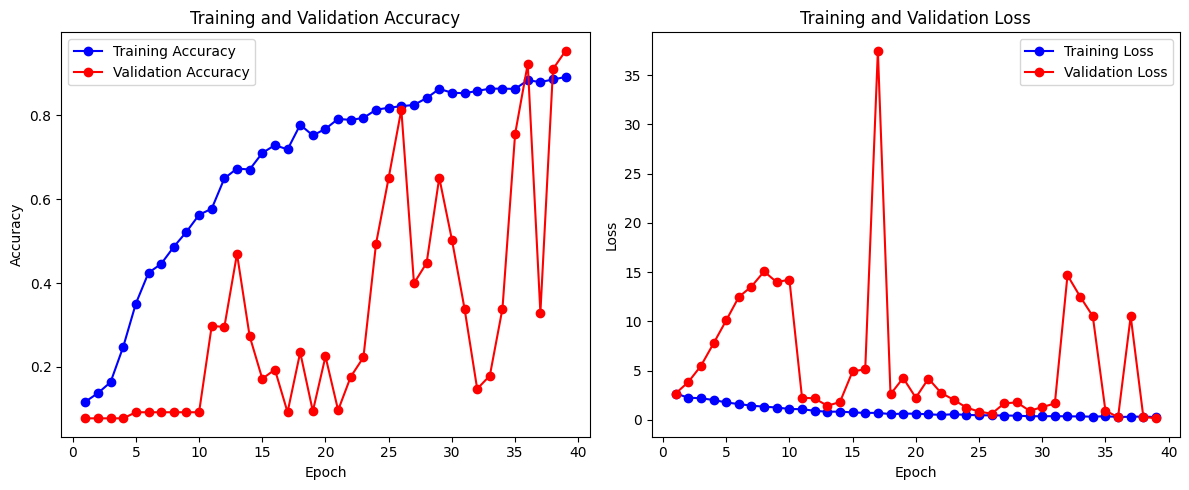

In [13]:
import matplotlib.pyplot as plt

# Extract metrics
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(accuracy) + 1)

# Plot accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, accuracy, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


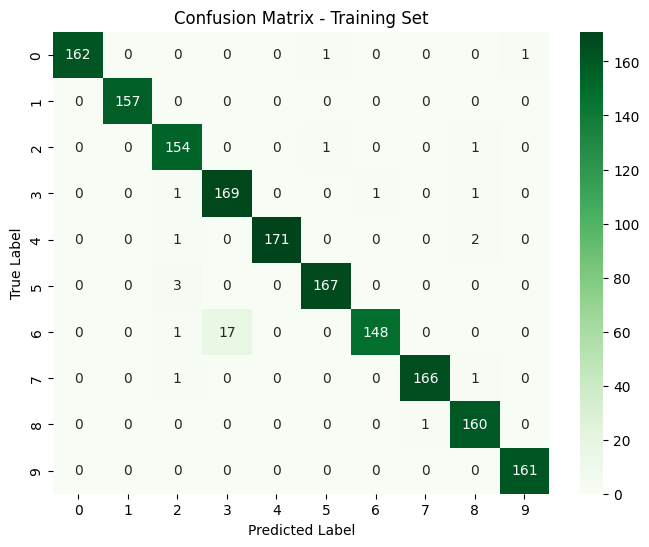

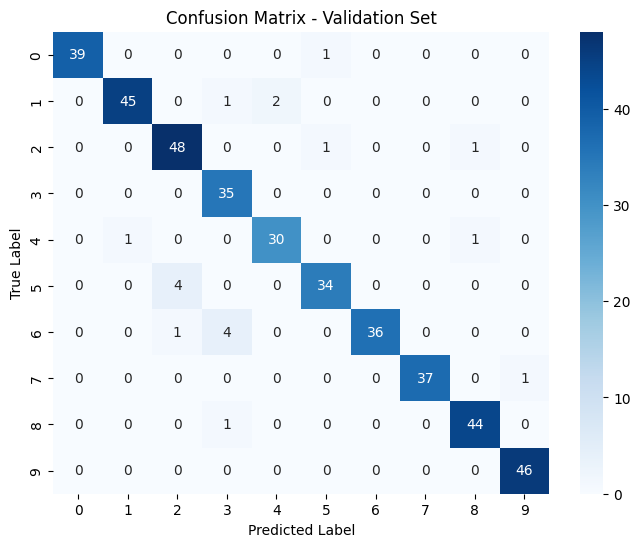

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get true and predicted labels
Y_train_true = np.argmax(Y_train, axis=1)
Y_train_pred = np.argmax(model.predict(X_train), axis=1)

Y_val_true = np.argmax(Y_val, axis=1)
Y_val_pred = np.argmax(model.predict(X_val), axis=1)

# Training set heatmap
plt.figure(figsize=(8, 6))
cm_train = confusion_matrix(Y_train_true, Y_train_pred)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens', xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - Training Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Validation set heatmap
plt.figure(figsize=(8, 6))
cm_val = confusion_matrix(Y_val_true, Y_val_pred)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - Validation Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [15]:
# ------------------------
# Evaluate
# ------------------------
Y_train_pred = np.argmax(model.predict(X_train), axis=1)
Y_val_pred = np.argmax(model.predict(X_val), axis=1)

print("Training set performance:")
print(classification_report(Y_train_int, Y_train_pred))

print("Validation set performance:")
print(classification_report(Y_val_int, Y_val_pred))


52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Training set performance:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       164
           1       1.00      1.00      1.00       157
           2       0.96      0.99      0.97       156
           3       0.91      0.98      0.94       172
           4       1.00      0.98      0.99       174
           5       0.99      0.98      0.99       170
           6       0.99      0.89      0.94       166
           7       0.99      0.99      0.99       168
           8       0.97      0.99      0.98       161
           9       0.99      1.00      1.00       161

    accuracy                           0.98      1649
   macro avg       0.98      0.98      0.98      1649
weighted avg       0.98      0.98      0.98      1649

Validation set performance:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        4

In [19]:
model.save('my_cnn_model.h5')